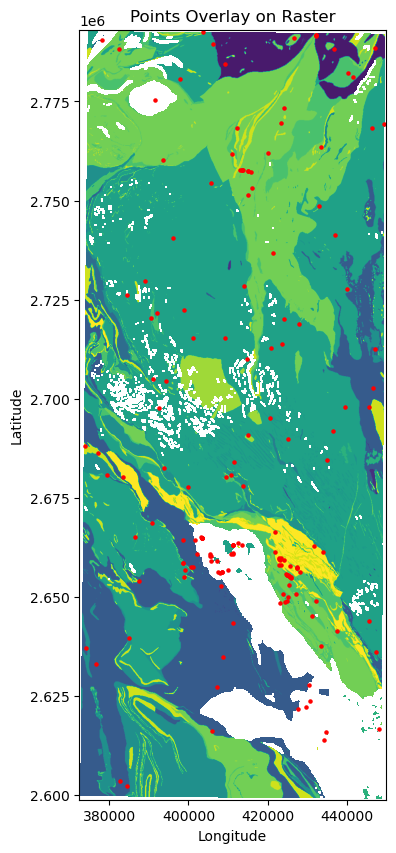

           X           Y  Label  BP1.tif     BP2.tif     BP3.tif     BP4.tif  \
0  433843.11  2661416.25      1    255.0    0.000000  115.799828  207.413559   
1  431700.35  2662751.93      1    255.0    0.000000  108.427483  192.043564   
2  422935.39  2658106.14      1    255.0  214.397232  185.510422  204.100418   
3  423355.93  2658039.29      1    255.0  222.186798  176.832687  202.594147   
4  424065.61  2659225.79      1    255.0  252.037537  130.180481  206.646500   

      BP5.tif     BP6.tif     BP7.tif     BP8.tif     BP9.tif   BP10.tif  \
0  137.451813  119.482117  236.360657    0.000000  241.339279  33.138756   
1  104.640007  115.450027  234.360626  232.826096  250.446426  36.603897   
2  146.925598   98.442238  234.758972  184.446640  255.000000  22.991154   
3  146.551285   88.529594  234.966248  176.383408  255.000000  21.618095   
4  127.662132   99.104996  235.842178  204.604752  227.678574  25.922649   

    BP11.tif    BP12.tif    BP13.tif   BP14.tif   BP15.tif    

In [1]:
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os

# Directory containing raster files

raster_dir = "C:/Users/AMD NR/Untitled Folder/RajML_py/Au_package"  # Update this path

# List of raster file names
raster_files = [f"BP{i}.tif" for i in range(1, 18)]

# Load the points from the CSV file
points_df = pd.read_csv("AuTS04.csv")

# Create a DataFrame to store results
results_df = points_df.copy()

# Iterate through each raster file
for raster_file in raster_files:
    raster_path = os.path.join(raster_dir, raster_file)
    try:
        with rasterio.open(raster_path) as raster:
            # Extract raster values at the point locations
            coordinates = [(x, y) for x, y in zip(points_df['X'], points_df['Y'])]
            raster_values = [val[0] for val in raster.sample(coordinates)]
            
            # Add raster values to the DataFrame
            results_df[raster_file] = raster_values
    except rasterio.errors.RasterioIOError:
        # Handle the case where the raster file cannot be opened
        results_df[raster_file] = None
# Plotting example: plotting the first raster
fig, ax = plt.subplots(figsize=(10, 10))
if raster_files:
    # Load the first raster to show as an example
    with rasterio.open(os.path.join(raster_dir, raster_files[0])) as raster:
        rasterio.plot.show(raster, ax=ax)
    
    # Overlay the points on the raster plot
    ax.scatter(points_df['X'], points_df['Y'], color='red', s=5)

# Show the plot
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Points Overlay on Raster')
plt.show()

# Display the first few rows with the extracted raster values
print(results_df.head())

# Optionally, save the results to a CSV file
results_df.to_csv("extracted_raster_values.csv", index=False)


In [2]:
#restructuring the results_dataframe for random Forest classifcation
# Drop the first two columns and send label column to the last 
#ML_df is the master dataframe for classification 
ML_df = results_df.drop(columns=['X', 'Y'])
# Extract the third column (Feature3 in this example)
third_column = results_df['Label']

# Drop the third column from the original DataFrame
ML_df = ML_df.drop(columns=['Label'])

# Add the third column to the end of the DataFrame
ML_df['Label'] = third_column 

print(ML_df)
ML_df.to_csv('Cu_ML_base.csv', index=False)

     BP1.tif     BP2.tif     BP3.tif     BP4.tif     BP5.tif     BP6.tif  \
0      255.0    0.000000  115.799828  207.413559  137.451813  119.482117   
1      255.0    0.000000  108.427483  192.043564  104.640007  115.450027   
2      255.0  214.397232  185.510422  204.100418  146.925598   98.442238   
3      255.0  222.186798  176.832687  202.594147  146.551285   88.529594   
4      255.0  252.037537  130.180481  206.646500  127.662132   99.104996   
..       ...         ...         ...         ...         ...         ...   
167    204.0   98.398285   94.529785  198.710861  169.721420  110.891037   
168    153.0   69.273697   49.504745  210.245972  206.472519  103.041245   
169     85.0   25.500000  244.350983  201.254898  136.868378   92.199738   
170     85.0   79.827629  106.491119  179.729431  117.239853  111.739075   
171    255.0   99.971703   89.245949  185.844604  135.200302  123.934326   

        BP7.tif     BP8.tif     BP9.tif   BP10.tif   BP11.tif    BP12.tif  \
0    236.3

In [3]:
# Example DataFrame loading
# df = pd.read_csv('your_data.csv')

# Assume the last column is the label
X = ML_df.iloc[:, :-1]  # Features
y = ML_df.iloc[:, -1]   # Labels

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

...

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [22:37:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

Best Parameters from Grid Search:
 {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Evaluation on Validation Set
Confusion Matrix:
 [[16  2]
 [ 0 17]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       0.89      1.00      0.94        17

    accuracy                           0.94        35
   macro avg       0.95      0.94      0.94        35
weighted avg       0.95      0.94      0.94        35

Accuracy Score: 0.9428571428571428
ROC AUC Score: 0.9836601307189542


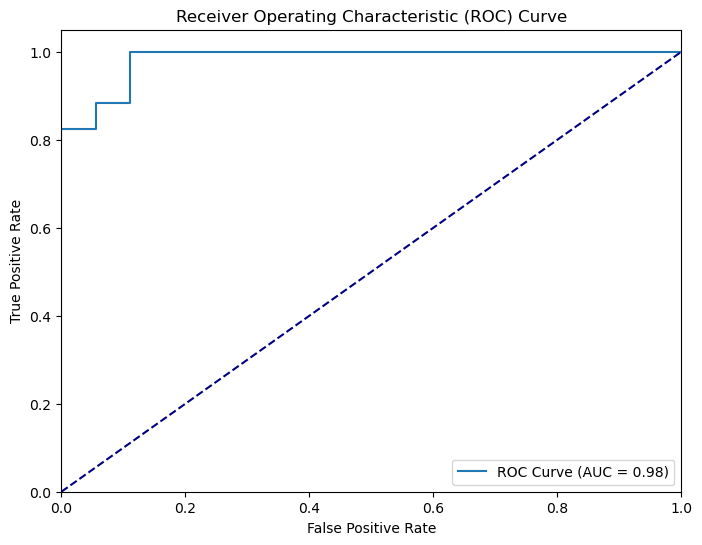

Wall time: 1min 12s


In [4]:
%%time
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assuming X and y are your features and labels
# Split your data into training and validation sets (80% train, 20% validation)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize the XGBClassifier
xgb_clf = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, n_jobs=1)

# Set up the parameter grid for GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],  # step size shrinkage
    'max_depth': [3, 5, 6],             # maximum depth of trees
    'n_estimators': [100, 200, 300],     # number of boosting rounds
    'subsample': [0.7, 0.8, 1.0],       # subsample ratio of training instances
    'colsample_bytree': [0.7, 0.8, 1.0] # subsample ratio of columns when constructing trees
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the model using grid search
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters from Grid Search:\n", best_params)

# Predictions for Validation Set
y_pred_valid = best_model.predict(X_valid)
y_proba_valid = best_model.predict_proba(X_valid)[:, 1]  # probabilities for ROC AUC

# Evaluation on Validation Set 
print("Evaluation on Validation Set")
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred_valid))
print("Classification Report:\n", classification_report(y_valid, y_pred_valid))
print("Accuracy Score:", accuracy_score(y_valid, y_pred_valid))
print("ROC AUC Score:", roc_auc_score(y_valid, y_proba_valid))

# Plotting the ROC curve
fpr, tpr, thresholds = roc_curve(y_valid, y_proba_valid)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_valid, y_proba_valid):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


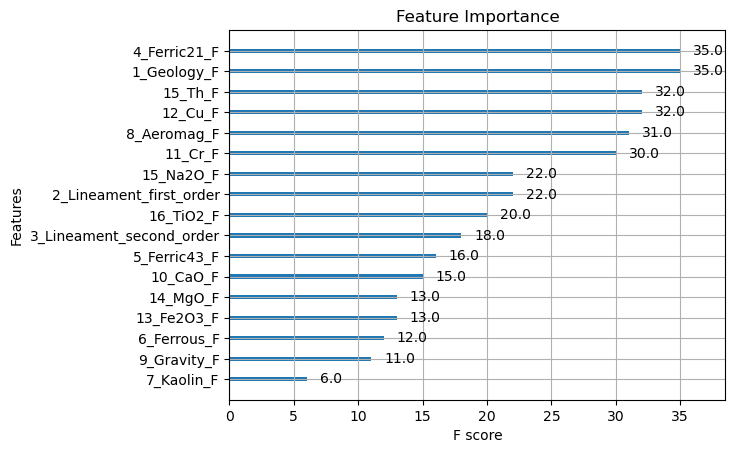

Model saved as 'xgboost_model.joblib'


In [5]:
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib

# Assuming you have already trained your model and stored it in best_model
# For example, best_model = xgb.train(params, dtrain)

# Feature importance plot
xgb.plot_importance(best_model, importance_type='weight')
plt.title('Feature Importance')  # You can customize the main title if needed

# Get the current axes (the plot area)
ax = plt.gca()

# Mapping of feature names to new labels
labels_mapping = {
    "BP1.tif": "1_Geology_F",
    "BP2.tif": "2_Lineament_first_order",
    "BP3.tif": "3_Lineament_second_order",
    "BP4.tif": "4_Ferric21_F",
    "BP5.tif": "5_Ferric43_F",
    "BP6.tif": "6_Ferrous_F",
    "BP7.tif": "7_Kaolin_F",
    "BP8.tif": "8_Aeromag_F",
    "BP9.tif": "9_Gravity_F",
    "BP10.tif": "10_CaO_F",
    "BP11.tif": "11_Cr_F",
    "BP12.tif": "12_Cu_F",
    "BP13.tif": "13_Fe2O3_F",
    "BP14.tif": "14_MgO_F",
    "BP15.tif": "15_Na2O_F",
    "BP16.tif": "15_Th_F",
    "BP17.tif": "16_TiO2_F"
}

# Get the current labels from the plot
current_labels = [item.get_text() for item in ax.get_yticklabels()]

# Update the labels using the mapping
new_labels = [labels_mapping.get(label.split("_")[0], label) for label in current_labels]

# Set the new labels
ax.set_yticklabels(new_labels)

plt.show()

# Save the trained model as a .joblib file
joblib.dump(best_model, 'xgboost_model.joblib')
print("Model saved as 'xgboost_model.joblib'")


In [6]:
import rasterio
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from joblib import load

# Load the trained model
rf_model = load('xgboost_model.joblib')  # Replace with your model file

# Define a function to read rasters and stack them
def stack_rasters(raster_paths):
    """Stack multiple raster files (features) into a single 3D array."""
    raster_stack = []
    min_height = float('inf')
    min_width = float('inf')

    # First, determine the minimum dimensions
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            height, width = src.shape
            min_height = min(min_height, height)
            min_width = min(min_width, width)

    # Now read and trim each raster
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            data = src.read(1)  # Read the first band of each raster
            trimmed_data = data[:min_height, :min_width]  # Trim to the minimum size
            raster_stack.append(trimmed_data)

    # Convert list of 2D arrays to a 3D numpy array
    return np.stack(raster_stack, axis=-1)

# Directory containing raster files
raster_dir = "C:/Users/AMD NR/Untitled Folder/RajML_py/Au_package"

# Paths to the 17 raster files (assumed to be named BP1.tif, BP2.tif, ..., BP17.tif)
raster_paths = [os.path.join(raster_dir, f'BP{i}.tif') for i in range(1, 18)]

# Load and stack rasters
try:
    stacked_rasters = stack_rasters(raster_paths)  # Shape: (min_height, min_width, num_features)
except ValueError as e:
    print(e)
    exit()

# Reshape data to match the model's input
height, width, num_features = stacked_rasters.shape
reshaped_data = stacked_rasters.reshape(-1, num_features)  # Shape: (num_pixels, num_features)

# Handle NaN values
reshaped_data = reshaped_data[~np.isnan(reshaped_data).any(axis=1)]

# Apply the Random Forest model to predict for each pixel
predictions = rf_model.predict(reshaped_data)

# Reshape predictions back to the original image shape
predictions_reshaped = predictions.reshape(height, width)

# Save the prediction as a new raster
output_raster_path = os.path.join(raster_dir, "XGBTS04_Au.tif")

with rasterio.open(raster_paths[0]) as src:
    meta = src.meta  # Get the metadata of the original raster
    meta.update(count=1, dtype='int16', nodata=-9999)  # Update metadata for the prediction raster

    # Write the prediction raster
    with rasterio.open(output_raster_path, 'w', **meta) as dst:
        dst.write(predictions_reshaped.astype('int16'), 1)  # Save as int16

print("Prediction raster saved at:", output_raster_path)


Prediction raster saved at: C:/Users/AMD NR/Untitled Folder/RajML_py/Au_package\XGBTS04_Au.tif
